# 04 Feature Engineering

Computes **band statistics** and **pixel-level spectral indices** from circular patch arrays.
For each band and each index: **mean and median** of valid pixels per patch.

**Inputs:**
- `data/patches/patches_{N}px.npz` — circular patch arrays (8 bands × N samples)
- `data/processed/dataset_base.csv` — reference turbidity labels (for analysis only)

**Outputs** in `data/processed/feature_engineering/`:
- `fe_{N}px.parquet` — 32 features per sample: `{band}_mean/median` × 8 + `{index}_mean/median` × 8

**Spectral indices (computed at pixel level):**

| Index | Formula | Sensitive to |
|-------|---------|--------------|
| NDTI  | (NIR−green)/(NIR+green) | Turbidity |
| NDWI  | (green−NIR)/(green+NIR) | Water / moisture |
| NDCI  | (red_edge−red)/(red_edge+red) | Chlorophyll-a |
| nir_green | NIR/green | Backscatter |
| red_green | red/green | Sediment |
| blue_green | blue/green | Clear vs turbid water |
| coastal_green | coastal/green | Coastal water |
| rededge_idx | (red_edge−red)/(red_edge+red) | Phytoplankton biomass |

In [7]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

## Configuration

In [8]:
PATCHES_DIR = Path('../data/patches')
PROC_DIR    = Path('../data/processed')
FE_DIR      = PROC_DIR / 'feature_engineering'
FE_DIR.mkdir(parents=True, exist_ok=True)

BAND_NAMES = ['coastal', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
BAND_IDX   = {n: i for i, n in enumerate(BAND_NAMES)}

INDEX_NAMES = [
    'ndti',          # (NIR-green)/(NIR+green) — turbidity / suspended material
    'ndwi',          # (green-NIR)/(green+NIR) — water / moisture
    'ndci',          # (red_edge-red)/(red_edge+red) — chlorophyll-a
    'nir_green',     # NIR / green ratio
    'red_green',     # red / green ratio
    'blue_green',    # blue / green ratio
    'coastal_green', # coastal / green ratio
    'rededge_idx',   # (red_edge-red)/(red_edge+red)
]

PATCH_CONFIGS = [
    {'px': 16,  'metres': 48},
    {'px': 32,  'metres': 96},
    {'px': 64,  'metres': 192},
    {'px': 128, 'metres': 384},
    {'px': 256, 'metres': 768},
]

META_COLS = ['ctd', 'date']
EPS       = 1e-6

print(f'Patches dir : {PATCHES_DIR}')
print(f'Feature dir : {FE_DIR}')
print(f'Bands       : {BAND_NAMES}')
print(f'Patch sizes : {[c["px"] for c in PATCH_CONFIGS]} px')

Patches dir : ../data/patches
Feature dir : ../data/processed/feature_engineering
Bands       : ['coastal', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
Patch sizes : [16, 32, 64, 128, 256] px


## Load reference turbidity (for analysis)

In [9]:
df_ref = pd.read_csv(PROC_DIR / 'dataset_base.csv')
df_ref['date'] = pd.to_datetime(df_ref['date']).dt.date
df_ref['ctd']  = df_ref['ctd'].astype(str)

print(f'Reference labels: {df_ref.shape}  |  CTDs: {df_ref["ctd"].nunique()}  |  dates: {df_ref["date"].nunique()}')
df_ref.describe()

Reference labels: (341, 3)  |  CTDs: 11  |  dates: 31


,turbidity
count,341.000000
mean,1.246729
std,1.262162
min,0.000000
25%,0.578752
50%,0.969705
75%,1.516380
max,10.488461


## Helper functions

In [10]:
def get_circle_mask(patch_px: int) -> np.ndarray:
    """Boolean (px, px) mask — True inside inscribed circle."""
    half = patch_px / 2.0
    yy, xx = np.ogrid[:patch_px, :patch_px]
    return (xx - half + 0.5) ** 2 + (yy - half + 0.5) ** 2 <= half ** 2


def load_patches(npz_path: Path, df_labels=None):
    """
    Load a patches .npz file, optionally merging with a turbidity DataFrame.
    If df_labels is provided (cols: ctd, date, turbidity), performs inner join.
    Returns (X: float32 (N,8,px,px), meta: DataFrame).
    """
    data = np.load(npz_path, allow_pickle=True)
    df_meta = pd.DataFrame({
        'ctd':  data['ctd'].astype(str),
        'date': pd.to_datetime(data['date']).map(lambda d: d.date()),
        '_idx': np.arange(len(data['ctd'])),
    })
    if df_labels is not None:
        merged = df_meta.merge(df_labels[['ctd', 'date', 'turbidity']], on=['ctd', 'date'], how='inner')
        X      = data['X'][merged['_idx'].values].astype(np.float32)
        meta   = merged.drop(columns='_idx').reset_index(drop=True)
    else:
        X    = data['X'].astype(np.float32)
        meta = df_meta.drop(columns='_idx').reset_index(drop=True)
    return X, meta


def compute_features(X: np.ndarray) -> pd.DataFrame:
    """
    Compute band and spectral-index statistics from a batch of circular patches.

    For each band   : mean and median of valid (non-NaN) pixels.
    For each index  : index computed at every valid pixel, then mean and median.

    Valid pixels are those inside the circle mask (corners are NaN in X).
    Index computation uses only pixels valid in ALL 8 bands.

    Parameters
    ----------
    X : (N, 8, px, px) float32

    Returns
    -------
    DataFrame (N, 32)  — 16 band cols + 16 index cols
    """
    N      = X.shape[0]
    px_sq  = X.shape[2] * X.shape[3]
    rows   = []

    for i in range(N):
        row = {}

        # ── Band statistics ──────────────────────────────────────────────
        for b, name in enumerate(BAND_NAMES):
            v = X[i, b].ravel()
            v = v[~np.isnan(v)]
            if len(v) == 0:
                row[f'{name}_mean']   = np.nan
                row[f'{name}_median'] = np.nan
            else:
                row[f'{name}_mean']   = float(v.mean())
                row[f'{name}_median'] = float(np.median(v))

        # ── Pixel-level spectral indices ──────────────────────────────────
        # Use pixels valid in all bands simultaneously for consistent index computation
        common = np.ones(px_sq, dtype=bool)
        for b in range(8):
            common &= ~np.isnan(X[i, b].ravel())

        if common.sum() == 0:
            for idx in INDEX_NAMES:
                row[f'{idx}_mean']   = np.nan
                row[f'{idx}_median'] = np.nan
        else:
            g       = X[i, BAND_IDX['green']    ].ravel()[common].astype(np.float64) + EPS
            nir     = X[i, BAND_IDX['nir']      ].ravel()[common].astype(np.float64) + EPS
            red     = X[i, BAND_IDX['red']      ].ravel()[common].astype(np.float64) + EPS
            re      = X[i, BAND_IDX['red_edge'] ].ravel()[common].astype(np.float64) + EPS
            blue    = X[i, BAND_IDX['blue']     ].ravel()[common].astype(np.float64) + EPS
            coastal = X[i, BAND_IDX['coastal']  ].ravel()[common].astype(np.float64) + EPS

            pixel_indices = {
                'ndti':          (nir - g)   / (nir + g),
                'ndwi':          (g   - nir) / (g   + nir),
                'ndci':          (re  - red) / (re  + red),
                'nir_green':     nir / g,
                'red_green':     red / g,
                'blue_green':    blue / g,
                'coastal_green': coastal / g,
                'rededge_idx':   (re  - red) / (re  + red),
            }

            for idx_name, vals in pixel_indices.items():
                row[f'{idx_name}_mean']   = float(vals.mean())
                row[f'{idx_name}_median'] = float(np.median(vals))

        rows.append(row)

    return pd.DataFrame(rows)


print('Helper functions loaded.')

Helper functions loaded.


## Feature extraction — all patch sizes

In [11]:
feat_cache = {}   # px → (feats_df, meta_with_turbidity)

for cfg in PATCH_CONFIGS:
    px       = cfg['px']
    npz_path = PATCHES_DIR / f'patches_{px}px.npz'

    if not npz_path.exists():
        print(f'  {px}px — file not found, skipping')
        continue

    # Load patches with reference turbidity for analysis
    X, meta = load_patches(npz_path, df_ref)
    feats   = compute_features(X)
    feat_cache[px] = (feats, meta)

    # Save features (ctd + date only, no turbidity)
    out_df   = pd.concat([meta[META_COLS].reset_index(drop=True),
                           feats.reset_index(drop=True)], axis=1)
    out_path = FE_DIR / f'fe_{px}px.parquet'
    out_df.to_parquet(out_path, index=False)

    nan_frac = feats.isna().mean().mean()
    print(f'  {cfg["metres"]:4d} m | N={len(out_df):4d} | features={feats.shape[1]} '
          f'| nan={nan_frac:.3f} → {out_path.name}')

    48 m | N= 359 | features=32 | nan=0.000 → fe_16px.parquet
    96 m | N= 359 | features=32 | nan=0.000 → fe_32px.parquet
   192 m | N= 359 | features=32 | nan=0.000 → fe_64px.parquet
   384 m | N= 325 | features=32 | nan=0.000 → fe_128px.parquet
   768 m | N= 235 | features=32 | nan=0.000 → fe_256px.parquet


## Analysis — correlation with turbidity

Pearson r between each feature and base turbidity, broken down by patch size.

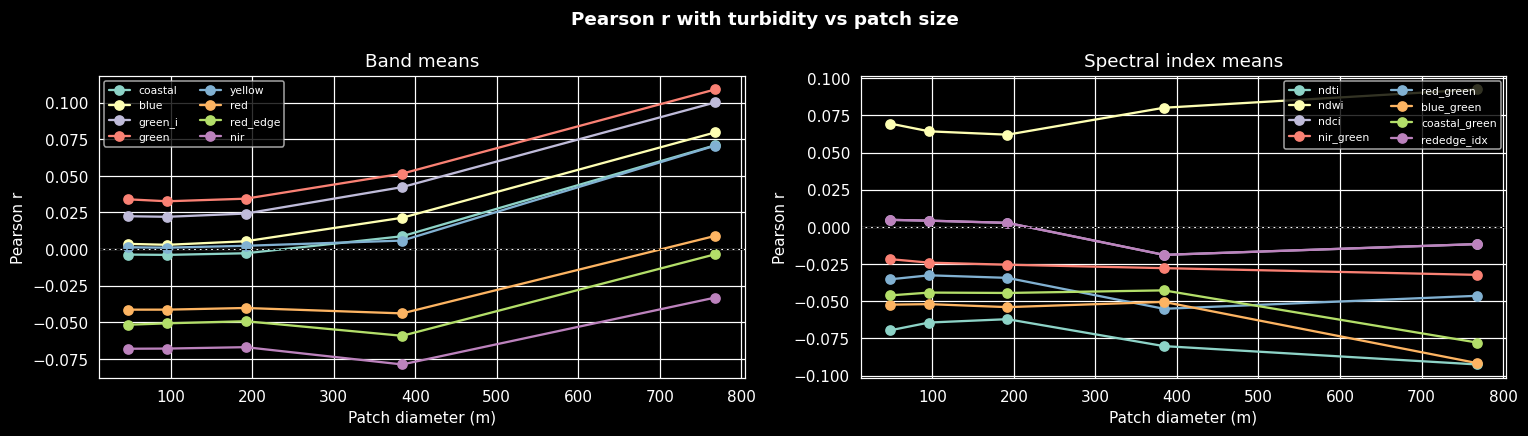

In [12]:
results = []
for cfg in PATCH_CONFIGS:
    px = cfg['px']
    if px not in feat_cache:
        continue
    feats, meta = feat_cache[px]
    df_tmp = pd.concat([meta[['turbidity']].reset_index(drop=True),
                         feats.reset_index(drop=True)], axis=1)
    for col in feats.columns:
        sub = df_tmp[['turbidity', col]].dropna()
        r   = sub.corr().iloc[0, 1] if len(sub) > 2 else np.nan
        results.append({'px': px, 'metres': cfg['metres'], 'feature': col, 'pearson_r': r})

df_corr = pd.DataFrame(results)

# Band means vs turbidity across patch sizes
band_mean_feats  = [f'{b}_mean' for b in BAND_NAMES]
index_mean_feats = [f'{idx}_mean' for idx in INDEX_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Pearson r with turbidity vs patch size', fontweight='bold')

for ax, feat_group, title in [
    (axes[0], band_mean_feats,  'Band means'),
    (axes[1], index_mean_feats, 'Spectral index means'),
]:
    for feat in feat_group:
        sub = df_corr[df_corr['feature'] == feat]
        if len(sub):
            ax.plot(sub['metres'], sub['pearson_r'], marker='o', label=feat.replace('_mean', ''))
    ax.axhline(0, color='black', lw=0.7, ls='--')
    ax.set_xlabel('Patch diameter (m)')
    ax.set_ylabel('Pearson r')
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## Analysis — spectral indices at reference patch (64 px)

For the reference patch size: correlation barplot, boxplots by turbidity quartile, scatter vs turbidity.

In [ ]:
ref_px = 64
if ref_px in feat_cache:
    feats_ref, meta_ref = feat_cache[ref_px]
    df_ref64 = pd.concat([meta_ref[['turbidity']].reset_index(drop=True),
                           feats_ref.reset_index(drop=True)], axis=1)

    idx_mean_cols = [f'{idx}_mean' for idx in INDEX_NAMES]
    corrs = df_ref64[idx_mean_cols + ['turbidity']].corr()['turbidity'].drop('turbidity')
    corrs_sorted = corrs.sort_values()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Spectral indices — patch {ref_px}px ({ref_px*3} m diameter)', fontweight='bold')

    ax = axes[0]
    colours = ['#cc4422' if v > 0 else '#4488cc' for v in corrs_sorted]
    ax.barh(corrs_sorted.index.str.replace('_mean', ''), corrs_sorted.values, color=colours, alpha=0.82)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Pearson r with turbidity')
    ax.set_title('Correlation with turbidity')
    for i, (idx_name, val) in enumerate(corrs_sorted.items()):
        ax.text(val + 0.01 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=8)

    ax = axes[1]
    df_ref64['turb_q'] = pd.qcut(df_ref64['turbidity'], q=4,
                                   labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)'])
    cmap = plt.cm.tab10
    xticks = []
    for j, col in enumerate(idx_mean_cols):
        vals_by_q = [df_ref64.loc[df_ref64['turb_q'] == q, col].dropna().values
                     for q in df_ref64['turb_q'].cat.categories]
        positions = [j * 5 + k for k in range(4)]
        bp = ax.boxplot(vals_by_q, positions=positions, widths=0.7,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=1.5))
        for patch in bp['boxes']:
            patch.set_facecolor(cmap(j / len(idx_mean_cols)))
            patch.set_alpha(0.65)
        xticks.append((j * 5 + 1.5, col.replace('_mean', '')))
    ax.set_xticks([x for x, _ in xticks])
    ax.set_xticklabels([n for _, n in xticks], rotation=30, ha='right', fontsize=8)
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_ylabel('Index value')
    ax.set_title('Distribution by turbidity quartile')

    ax = axes[2]
    for j, col in enumerate(idx_mean_cols):
        sub = df_ref64[['turbidity', col]].dropna()
        ax.scatter(sub[col], sub['turbidity'], s=16, alpha=0.5,
                   color=cmap(j / len(idx_mean_cols)), label=col.replace('_mean', ''))
    ax.set_yscale('log')
    ax.set_xlabel('Index value')
    ax.set_ylabel('Turbidity (NTU, log scale)')
    ax.set_title('Index vs turbidity')
    ax.legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'pearson_r': corrs.rename(lambda x: x.replace('_mean', '')),
        'mean':      df_ref64[idx_mean_cols].mean().rename(lambda x: x.replace('_mean', '')).round(4),
        'std':       df_ref64[idx_mean_cols].std().rename(lambda x: x.replace('_mean', '')).round(4),
    }).sort_values('pearson_r', ascending=False)
    print(f'Spectral index summary (ref: {ref_px}px):')
    display(summary)

## Analysis — all features correlation (64 px reference)

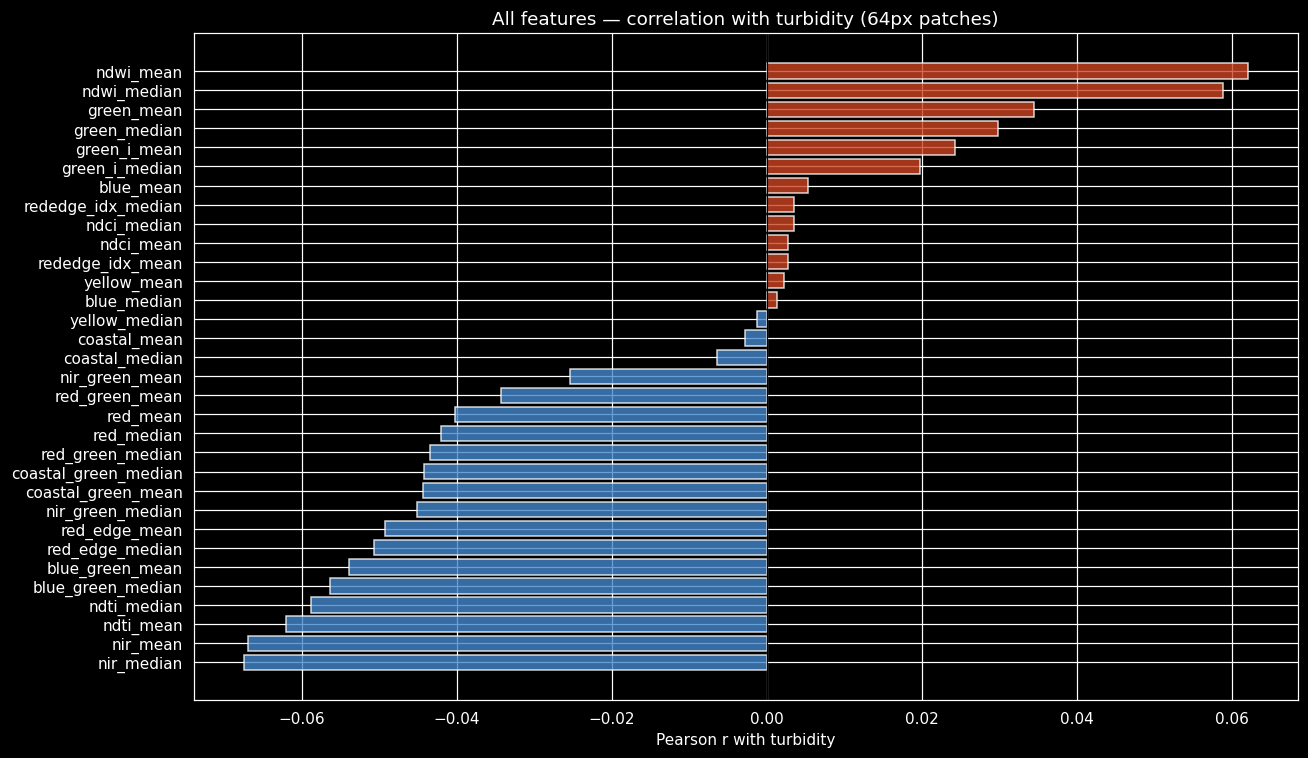

Top 5 positive:
green_i_mean    0.024267
green_median    0.029878
green_mean      0.034410
ndwi_median     0.058839
ndwi_mean       0.062035

Top 5 negative:
nir_median          -0.067462
nir_mean            -0.066891
ndti_mean           -0.062035
ndti_median         -0.058839
blue_green_median   -0.056282


In [14]:
ref_px = 64
if ref_px in feat_cache:
    feats_ref, meta_ref = feat_cache[ref_px]
    df_tmp = pd.concat([meta_ref[['turbidity']].reset_index(drop=True),
                         feats_ref.reset_index(drop=True)], axis=1)

    all_corrs = df_tmp.corr()['turbidity'].drop('turbidity').sort_values()

    fig, ax = plt.subplots(figsize=(12, 7))
    colours = ['#cc4422' if v > 0 else '#4488cc' for v in all_corrs]
    ax.barh(all_corrs.index, all_corrs.values, color=colours, alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Pearson r with turbidity')
    ax.set_title(f'All features — correlation with turbidity ({ref_px}px patches)')
    plt.tight_layout()
    plt.show()

    print('Top 5 positive:')
    print(all_corrs.tail(5).to_string())
    print('\nTop 5 negative:')
    print(all_corrs.head(5).to_string())

## Summary of generated feature files

In [15]:
rows = []
for f in sorted(FE_DIR.glob('fe_*px.parquet')):
    df_tmp = pd.read_parquet(f)
    feat_cols = [c for c in df_tmp.columns if c not in META_COLS]
    rows.append({
        'file':         f.name,
        'samples':      len(df_tmp),
        'features':     len(feat_cols),
        'nan_fraction': round(df_tmp[feat_cols].isna().mean().mean(), 4),
        'feature_cols': feat_cols[:4],
    })

summary = pd.DataFrame(rows).set_index('file')
print(f'Feature files generated: {len(summary)}')
print(f'Features per file: {summary["features"].unique()} (band mean/median × 8 + index mean/median × 8 = 32)')
display(summary[['samples', 'features', 'nan_fraction']])

Feature files generated: 5
Features per file: [32] (band mean/median × 8 + index mean/median × 8 = 32)


,samples,features,nan_fraction
file,,,
fe_128px.parquet,325,32,0.0
fe_16px.parquet,359,32,0.0
fe_256px.parquet,235,32,0.0
fe_32px.parquet,359,32,0.0
fe_64px.parquet,359,32,0.0
